In [1]:
import ipywidgets as widgets
from sksurv.datasets import load_aids, load_bmt, load_cgvhd, load_breast_cancer, load_flchain, load_gbsg2, load_whas500, load_veterans_lung_cancer
from IPython.display import display

dataset_names = ['aids', 'bmt', 'cgvhd', 'breast_cancer', 'flchain', 'gbsg2', 'whas500', 'veterans_lung_cancer']
dataset_selector = widgets.Dropdown(
    options=dataset_names,
    value='veterans_lung_cancer',
    description='Dataset:'
)
display(dataset_selector)

client_count_selector = widgets.IntSlider(
    value=5,
    min=2,
    max=10,
    step=1,
    description='Client Count:'
)
display(client_count_selector)

update_method_selector = widgets.Dropdown(
    options=['all', 'constant'],
    value='all',
    description='Update Method:'
)
display(update_method_selector)

test_size_selector = widgets.FloatSlider(
    value=0.3,
    min=0.1,
    max=0.9,
    step=0.05,
    description='Test Size:'
)
display(test_size_selector)

Dropdown(description='Dataset:', index=7, options=('aids', 'bmt', 'cgvhd', 'breast_cancer', 'flchain', 'gbsg2'…

IntSlider(value=5, description='Client Count:', max=10, min=2)

Dropdown(description='Update Method:', options=('all', 'constant'), value='all')

FloatSlider(value=0.3, description='Test Size:', max=0.9, min=0.1, step=0.05)

In [42]:
from federated_rsf.models import LocalRandomSurvivalForest, FederatedRandomSurvivalForest
from federated_rsf.schema import DatasetSchema, SchemaAligner, SchemaCreator
from federated_rsf.testing import federate_data
from sksurv.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

n_clients = client_count_selector.value

dataset_name_to_loader = {
    'aids': load_aids,
    'bmt': load_bmt,
    'cgvhd': load_cgvhd,
    'breast_cancer': load_breast_cancer,
    'flchain': load_flchain,
    'gbsg2': load_gbsg2,
    'whas500': load_whas500,
    'veterans_lung_cancer': load_veterans_lung_cancer
}

X, Y = dataset_name_to_loader[dataset_selector.value]()

def convert_to_federated_datasets(X, Y, n_clients, random_state=0, shuffle=True):
    X_list, Y_list = federate_data(X, Y, clients=n_clients, random_state=random_state, shuffle=shuffle)
    X_list = [OneHotEncoder().fit_transform(X) for X in X_list]

    schema_list = [DatasetSchema(X.columns) for X in X_list]
    schema_creator = SchemaCreator()
    federated_schemas = schema_creator.fit_transform(schema_list)

    X_aligned_list = []
    local_schema_aligners = []
    for X_local, schema in zip(X_list, federated_schemas):
        aligner = SchemaAligner().fit(schema)
        X_aligned = aligner.transform(X_local)
        X_aligned_list.append(X_aligned)
        local_schema_aligners.append(aligner)
    return X_aligned_list, Y_list

X_list, Y_list = convert_to_federated_datasets(X, Y, n_clients, random_state=0)

In [43]:
local_models = [LocalRandomSurvivalForest(random_state=0, update_method=update_method_selector.value) for _ in range(n_clients)]
global_model = LocalRandomSurvivalForest(random_state=0, update_method=update_method_selector.value)

def split_data(X_list, Y_list, test_size_selector):
    X_trains, X_tests, Y_trains, Y_tests = [], [], [], []

    for X_local, Y_local in zip(X_list, Y_list):

        X_train, X_test, Y_train, Y_test = train_test_split(X_local, Y_local, test_size=test_size_selector.value, random_state=0)
        X_trains.append(X_train)
        X_tests.append(X_test)
        Y_trains.append(Y_train)
        Y_tests.append(Y_test)

    return X_trains, Y_trains, X_tests, Y_tests

def fit_and_federate_models(X_trains, Y_trains, local_models):
    for X_train, Y_train, local_model in zip(X_trains, Y_trains, local_models):
        local_model.fit(X_train, Y_train)

    federated_model = FederatedRandomSurvivalForest(local_models=local_models)
    federated_model.distribute_trees()

    return local_models

def train_global_model(X_trains, Y_trains, global_model):
    X_global_train = pd.concat(X_trains, ignore_index=True)
    Y_global_train = np.concatenate(Y_trains)

    global_model.fit(X_global_train, Y_global_train)

    return global_model

X_trains, Y_trains, X_tests, Y_tests = split_data(X_list, Y_list, test_size_selector)

local_models = fit_and_federate_models(X_trains, Y_trains, local_models)
global_model = train_global_model(X_trains, Y_trains, global_model)

In [44]:
def evaluate_models_text(local_models, global_model, X_tests, Y_tests):
    for i, (local_model, X_test, Y_test) in enumerate(zip(local_models, X_tests, Y_tests)):
        global_c_index = global_model.score(X_test, Y_test)
        print(f"Client {i+1}")
        print(f"Global model C-index: {global_c_index:.4f}")
        local_model.use_local_estimators()
        c_index = local_model.score(X_test, Y_test)
        print(f"Local model C-index: {c_index:.4f}")
        local_model.use_federated_estimators()
        federated_c_index = local_model.score(X_test, Y_test)
        if global_c_index < federated_c_index > c_index:
            color = "\033[32m"  # Green
        elif global_c_index >= federated_c_index <= c_index:
            color = "\033[31m"  # Red
        else:
            color = "\033[33m"  # Yellow
        print(f"Federated model C-index: {color}{federated_c_index:.4f}\033[0m")
        print(f"Number of estimators in federated model: {local_model.n_estimators}")
        print("-" * 30)

evaluate_models_text(local_models, global_model, X_tests, Y_tests)

Client 1
Global model C-index: 0.7912
Local model C-index: 0.8418
Federated model C-index: 0.8350
Number of estimators in federated model: 100
------------------------------
Client 2
Global model C-index: 0.8824
Local model C-index: 0.8382
Federated model C-index: 0.8578
Number of estimators in federated model: 100
------------------------------
Client 3
Global model C-index: 0.8038
Local model C-index: 0.7057
Federated model C-index: 0.6930
Number of estimators in federated model: 100
------------------------------
Client 4
Global model C-index: 0.7356
Local model C-index: 0.7452
Federated model C-index: 0.7692
Number of estimators in federated model: 100
------------------------------
Client 5
Global model C-index: 0.7111
Local model C-index: 0.7365
Federated model C-index: 0.7460
Number of estimators in federated model: 100
------------------------------


In [45]:
def collect_c_indexes(repetitions, update_method_selector, client_count_selector, test_size_selector):
    c_indexes = {'local': [], 'federated': [], 'global': []}
    for random_state in range(repetitions):
        local_models = [LocalRandomSurvivalForest(random_state=random_state, update_method=update_method_selector.value) for _ in range(client_count_selector.value)]
        global_model = LocalRandomSurvivalForest(random_state=random_state, update_method=update_method_selector.value)

        X_list, Y_list = convert_to_federated_datasets(X, Y, client_count_selector.value, random_state=random_state)
        X_trains, Y_trains, X_tests, Y_tests = split_data(X_list, Y_list, test_size_selector)

        local_models = fit_and_federate_models(X_trains, Y_trains, local_models)
        global_model = train_global_model(X_trains, Y_trains, global_model)

        for local_model, X_test, Y_test in zip(local_models, X_tests, Y_tests):
            global_c_index = global_model.score(X_test, Y_test)
            c_indexes['global'].append(global_c_index)
            local_model.use_local_estimators()
            c_index = local_model.score(X_test, Y_test)
            c_indexes['local'].append(c_index)
            local_model.use_federated_estimators()
            federated_c_index = local_model.score(X_test, Y_test)
            c_indexes['federated'].append(federated_c_index)

    return c_indexes


c_indexes = collect_c_indexes(10,update_method_selector=update_method_selector, client_count_selector=client_count_selector, test_size_selector=test_size_selector)

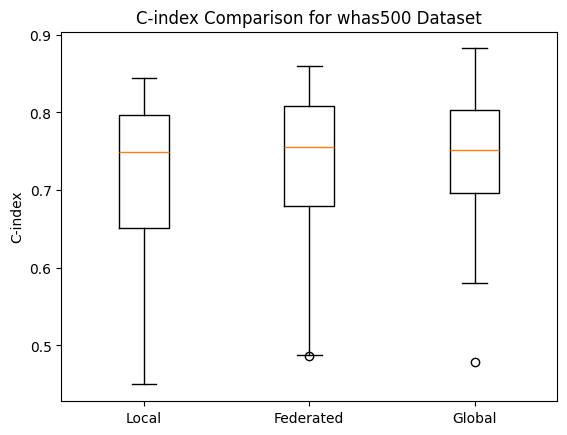

In [46]:
from matplotlib import pyplot as plt

plt.boxplot([c_indexes['local'], c_indexes['federated'], c_indexes['global']], tick_labels=['Local', 'Federated', 'Global'])
plt.ylabel('C-index')
plt.title(f"C-index Comparison for {dataset_selector.value} Dataset")
plt.show()


In [47]:
len(X)

500